Numerical Results

In this section, we calculate the current density due to SEI for all models with the following parameters:

In [21]:
%cd /home/kawamanmi/Projects/PyBaMM
import pybamm
import numpy as np

# Stadardised Formation Cycling Bham group
# no_cycles = 1
# exp = pybamm.Experiment( [("Charge at C/20 until 4.2 V",
#                            "Hold at 4.2 V for 1 hours", 
#                            "Hold at 4.2 V until 2.5 mA", 
#                            "Discharge at C/20 until 2.5 V",
#                            "Charge at C/20 until 3.8 V",
#                            "Hold at 3.8 V for 1 hours"
#                            )]* no_cycles)

no_cycles = 2
exp = pybamm.Experiment(
    [("Charge at C/20 until 4.2 V",
      "Rest for 5 hours",
      "Discharge at C/20 until 2.5 V",
      "Rest for 5 hours",
      )]* no_cycles )
# The SEI layer considered as one layer here, 
# so in all equations if there were Outer_or inner they have been removed


k_sei =[ 1e-19, 1e-15, 1e-10, 1e-19, 1e-15]
D_sol = [1e-20,2e-22, 1e-22 ,1e-20, 2e-22] 
params = []
for i in range(0, len(k_sei)):
  param=pybamm.ParameterValues("Chen2020")
  param['Initial inner SEI thickness [m]']=5e-13
  param['Initial outer SEI thickness [m]']=5e-13
  param['SEI kinetic rate constant [m.s-1]'] =k_sei[i]
  param['Outer SEI solvent diffusivity [m2.s-1]' ]=D_sol[i]
  param['Bulk solvent concentration [mol.m-3]']= 4541.0
  param['SEI open-circuit potential [V]'] = 0.8
  param['Inner SEI electron conductivity [S.m-1]']=8.5e-14
  param['SEI lithium ion conductivity [S.m-1]']=1e-8
  param['Inner SEI lithium interstitial diffusivity [m2.s-1]']=1e-15
  param['Lithium interstitial reference concentration [mol.m-3]']=1000
  # This has been used fro Kolzenberg model 
  param['SEI reaction exchange current density [A.m-2]'] = 7.04e-5
  params.append(param)


/home/kawamanmi/Projects/PyBaMM


In [22]:
# models[0].variable_names()

In [23]:

sei_options = ['ec reaction limited',
               'ec reaction limited', 'ec reaction limited', "reaction limited", 'solvent-diffusion limited'
               ]
models = [pybamm.lithium_ion.SPM({"particle": "uniform profile",
                                  "SEI": sei_option}) for sei_option in sei_options]


pybamm.settings.max_y_value = 1000000000
solver = pybamm.CasadiSolver(mode="safe")

sims = [pybamm.Simulation(model, parameter_values=params[index],
                          experiment=exp, solver=solver) for index, model in enumerate(models)]
sols = [sim.solve(initial_soc=0) for sim in sims]

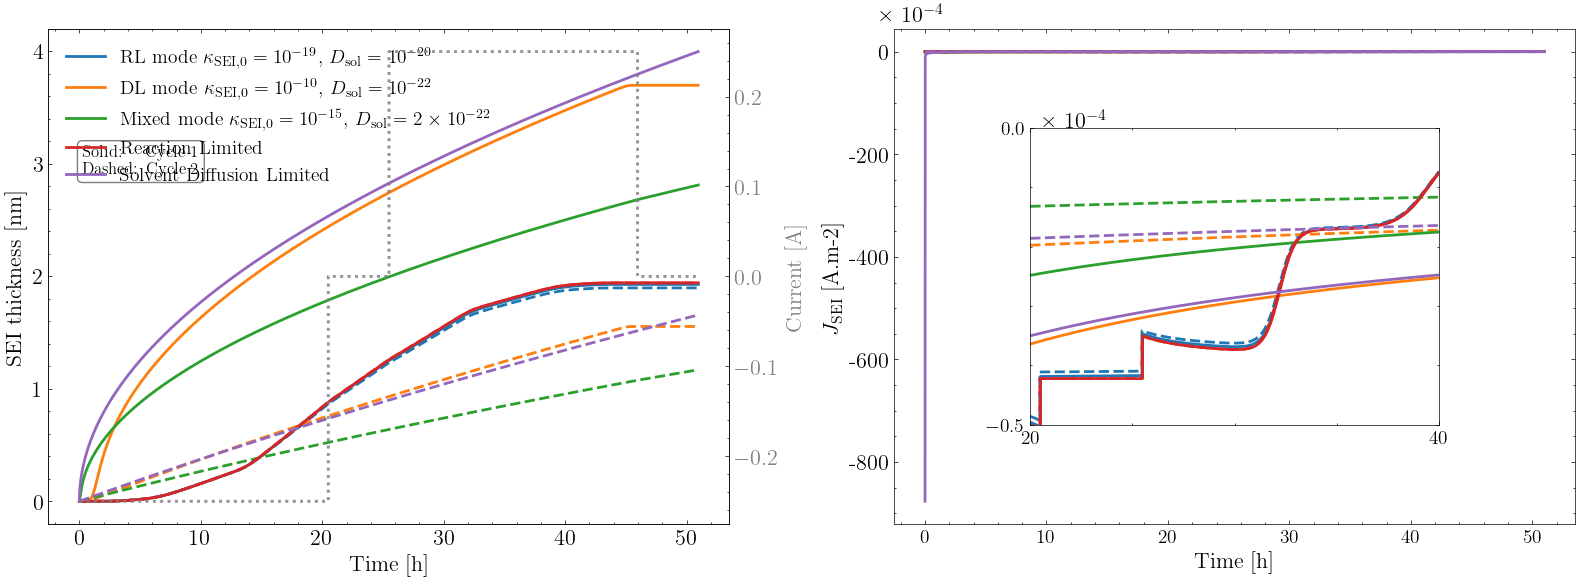

In [24]:

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import scienceplots
import matplotlib.cm as cm
import matplotlib.ticker as ticker
plt.style.use('science')  # Use the 'science' style
cmap = cm.get_cmap('tab10')  # Colour map (there are many others)

# plt.rcParams["font.family"] = "DejaVu Sans"

# linestyles = ["-", "--", "-.", ":", "-"]
line_styles = ["-", "--"]
# colors = ['darkred', 'darkblue', 'red',  'blue', 'lightcoral', 'lightblue']
# index_color = 0
fig, axs = plt.subplots(1, 2, figsize=(16, 6))  # 1 row, 2 columns


label_models = [
    'RL mode $\kappa_\mathrm{SEI, 0}=10^{-19}$, $D_\mathrm{sol}=10^{-20}$',
    'DL mode  $\kappa_\mathrm{SEI, 0}=10^{-10}$, $D_\mathrm{sol}=10^{-22}$',
    'Mixed mode $\kappa_\mathrm{SEI, 0}=10^{-15}$, $D_\mathrm{sol}=2 \\times 10^{-22}$', "Reaction Limited", "Solvent Diffusion Limited"]


# First plot
ax1 = axs[0]
ax2 = ax1.twinx()  # Create a second y-axis on the right side

for index, sol in enumerate(sols):
    for cycle in range(no_cycles):
        t_min = np.min(sol.cycles[cycle]["Time [h]"].entries)
        t = sol.cycles[cycle]["Time [h]"].entries - t_min
        L_min = np.min(
            sol.cycles[cycle]['X-averaged negative total SEI thickness [m]'].entries)
        L_sei = (
            sol.cycles[cycle]['X-averaged negative total SEI thickness [m]'].entries - L_min) * 1e9
        current = sol.cycles[cycle]['Current [A]'].entries

        if cycle == 0:
            ax1.plot(t, L_sei, label=(
                label_models[index]), linestyle=line_styles[0], linewidth=2, color=cmap(index))
            ax2.plot(
                t, current,  zorder=-3, linestyle=":", linewidth=2, color='gray', alpha=0.3)
        else:
            ax1.plot(
                t, L_sei, linestyle=line_styles[1], linewidth=2, color=cmap(index))
            # ax2.plot(
            #     t, current, linestyle=line_styles[1], linewidth=2, color='gray', alpha=0.5)

# Set 4-5 ticks on the left y-axis
# ax1.set_yticks(np.roundnp.linspace(ax1.get_ybound()[0], ax1.get_ybound()[1], 5))
ax1.set_yticks(np.linspace(0, 4, 5))

ax1.legend(fontsize=14, facecolor='white', framealpha=1)
ax1.set_xlabel("Time [h]", fontsize=16)
ax1.set_ylabel("SEI thickness [nm]", fontsize=16, color='black')
ax1.tick_params(axis='both', which='major', labelsize=16)
ax1.tick_params(axis='y', labelcolor='black')

ax2.set_ylabel("Current [A]", fontsize=16, color='gray')
ax2.tick_params(axis='both', which='major', labelsize=16, labelcolor='gray')


ax1.text(0.05, 0.7, 'Solid: \\ \\ \\ Cycle 1\nDashed: Cycle 2', transform=ax1.transAxes, fontsize=12,
         verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

# # Second plot
for index, sol in enumerate(sols):
    for cycle in range(no_cycles):
        t_min = np.min(sol.cycles[cycle]["Time [h]"].entries)
        t = sol.cycles[cycle]["Time [h]"].entries-t_min
        J_sei_last = sol.cycles[cycle]['X-averaged negative electrode SEI interfacial current density [A.m-2]'].entries[0]
        J_sei = (
            sol.cycles[cycle]['X-averaged negative electrode SEI interfacial current density [A.m-2]'].entries - J_sei_last*0)
        axs[1].plot(t,
                    J_sei*1e4,
                    linestyle=line_styles[cycle % 2], linewidth=2, color=cmap(index))

# Create an inset axes for the zoomed-in region
axins = inset_axes(axs[1], width="60%", height="60%",
                   loc='center')
for index, sol in enumerate(sols):
    for cycle in range(no_cycles):
        t_min = np.min(sol.cycles[cycle]["Time [h]"].entries)
        t = sol.cycles[cycle]["Time [h]"].entries-t_min
        J_sei_last = sol.cycles[cycle]['X-averaged negative electrode SEI interfacial current density [A.m-2]'].entries[0]
        J_sei = (
            sol.cycles[cycle]['X-averaged negative electrode SEI interfacial current density [A.m-2]'].entries - J_sei_last*0)
        axins.plot(t,
                   J_sei*1e4,
                   linestyle=line_styles[cycle % 2], linewidth=2, color=cmap(index))


axins.set_xlim(20, 40)
axins.set_ylim(-0.4, 0)
# Set the locations of the x and y ticks
axins.set_xticks([20, 40])
axins.set_yticks([-0.5, 0])

# Increase the font size of the tick labels
axins.tick_params(labelsize=14)
axins.text(0.03, 1.06, '× 10$^{-4}$', transform=axins.transAxes,
           fontsize=16, verticalalignment='top')


# axs[1].legend(fontsize=14)
axs[1].set_xlabel("Time [h]", fontsize=16)
axs[1].set_ylabel(
    "$J_\mathrm{SEI}$ [A.m-2] ", fontsize=16)
axs[1].yaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))
axs[1].tick_params(axis='both', which='major', labelsize=14)
axs[1].tick_params(axis='y', labelsize=16)
axs[1].text(-0.02, 1.05, '× 10$^{-4}$', transform=axs[1].transAxes,
            fontsize=16, verticalalignment='top')


plt.tight_layout()
plt.savefig("figure2.pdf", format='pdf', dpi=300)
plt.show()